# Imports

In [1]:
import os
from pathlib import Path
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
from backtester import BackTester

In [6]:
data_store=Path("../Prepared_Data_Store")

# BackTesting

## Trading Strategy-I:

### Here we will long the top returns and short the bottom returns values at a particular day as predicted by our Model-3

In [7]:
trading_strategy={
    "strategy":"returns_based",
    "values":{}
}

In [8]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model3_Factors",
    trading_strategy=trading_strategy
)

In [9]:
results=backtester.run_backtesting()

INFO: Model predictions loaded...
INFO: Missing Date Values added in Model Predictions...
INFO: Model Data Loader created...
INFO: Backtesting started for trading strategy-I...
INFO: Backtesting completed...


### Performance analysis using Pyfolio

#### Loading Benchmark Data

In [10]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [11]:
benchmark_data=benchmark_data.sp500_returns.tz_localize("UTC")

#### Extracting information from Zipline Results

In [12]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

In [13]:
LIVE_DATE="2016-02-24"

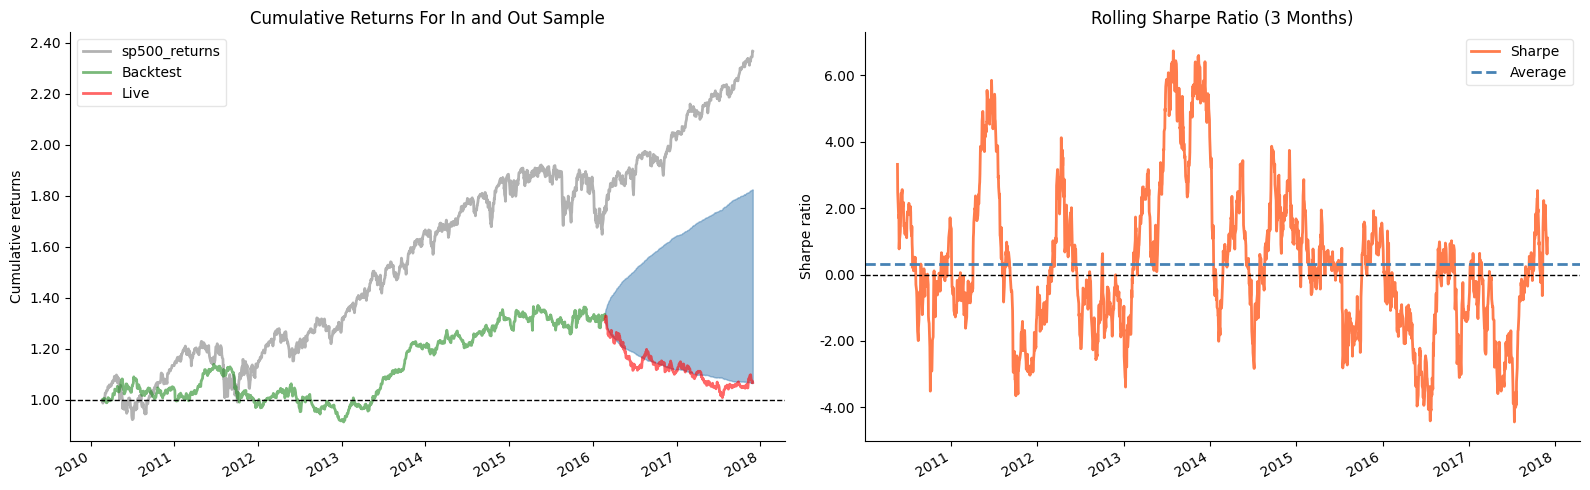

In [14]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,26.38,2015-05-07,2017-07-20,NaT,NaN
1,19.85,2011-06-22,2013-01-09,2013-10-01,595
2,8.70,2010-07-08,2011-01-10,2011-05-05,216
3,6.06,2014-12-03,2015-01-20,2015-04-17,98
4,5.45,2014-04-04,2014-06-19,2014-09-10,114


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.06%,-1.43%,1.12%
Fukushima,0.09%,-0.82%,0.86%
EZB IR Event,0.02%,-0.88%,2.30%
Flash Crash,0.44%,0.11%,0.74%
Apr14,-0.03%,-1.23%,0.95%
Oct14,-0.01%,-1.32%,1.05%
Fall2015,-0.14%,-1.37%,1.20%
Recovery,-0.01%,-3.04%,3.41%
New Normal,0.01%,-3.14%,4.38%


Top 10 long positions of all time,max
sid,
BLDR,40.26%
NVDA,23.56%
NFLX,22.82%
EXPE,21.36%
VRTX,20.42%
NRG,20.11%
STLD,19.73%
BIIB,19.48%
MOH,18.65%


Top 10 short positions of all time,max
sid,
BLDR,-39.18%
NFLX,-28.56%
NVDA,-28.47%
VRTX,-25.15%
NRG,-24.00%
MOH,-23.90%
AMD,-16.89%
EXPE,-16.56%
TMUS,-16.36%


Top 10 positions of all time,max
sid,
BLDR,40.26%
NFLX,28.56%
NVDA,28.47%
VRTX,25.15%
NRG,24.00%
MOH,23.90%
EXPE,21.36%
STLD,19.73%
BIIB,19.48%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$762785.74,$-1049109.90,$1811895.64
Gross profit,$22603676.91,$10395247.93,$12208428.98
Gross loss,$-21840891.17,$-11444357.82,$-10396533.34
Profit factor,$1.03,$0.91,$1.17
Avg. trade net profit,$10.30,$-29.96,$46.38
Avg. winning trade,$614.45,$623.25,$607.14
Avg. losing trade,$-596.42,$-634.35,$-559.59
Ratio Avg. Win:Avg. Loss,$1.03,$0.98,$1.08
Largest winning trade,$133666.07,$133666.07,$106213.10
Largest losing trade,$-43074.84,$-43074.84,$-33992.58


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 22:51:13.218007559,1 days 16:04:58.354866346,2 days 04:55:22.240323571
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,195 days 01:00:00,195 days 01:00:00,181 days 23:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.05%,0.06%,0.05%
Avg returns losing,-0.05%,-0.06%,-0.05%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.03%,0.03%,0.03%
Median returns losing,-0.03%,-0.03%,-0.02%
Largest winning trade,12.52%,12.52%,10.65%
Largest losing trade,-3.33%,-3.33%,-2.57%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.01%,0.01%,0.00%,0.00%,-0.00%,0.00%,0.01%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.01%,0.01%,0.00%,-0.00%,0.01%,-0.00%,0.00%,-0.00%,-0.00%,0.01%,0.00%,0.01%,-0.00%,0.00%,0.01%,0.01%,-0.00%,-0.01%,-0.00%,0.01%,0.01%,-0.00%,-0.01%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.02%,0.00%,0.00%,-0.00%,-0.01%,0.00%,-0.00%,0.01%,0.01%,-0.01%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.01%,0.00%,-0.01%,-0.00%,0.01%,0.01%,0.00%,-0.00%,-0.03%,-0.01%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.01%,0.00%,-0.01%,-0.00%,0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.10%,-0.00%,-0.01%,-0.01%,-0.00%,0.01%,0.01%,0.00%,-0.01%,-0.00%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.01%,-0.00%,-0.01%,0.00%,-0.01%,0.00%,-0.00%,0.00%,-0.01%,0.01%,-0.00%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,0.01%,-0.01%,0.01%,0.01%,-0.01%,0.01%,0.02%,-0.00%,0.01%,0.00%,0.00%,0.00%,0.01%,0.00%,0.00%,0.01%,0.01%,-0.00%,-0.01%,0.01%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,0.01%,0.01%,0.00%,-0.00%,-0.03%,0.00%,0.00%,-0.01%,0.00%,0.01%,-0.01%,-0.00%,-0.01%,-0.00%,-0.00%,-0.01%,0.01%,-0.00%,0.00%,0.03%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.01%,0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.02%,-0.01%,0.01%,0.01%,0.00%,-0.01%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,0.01%,0.00%,-0.00%,-0.01%,0.01%,-0.01%,0.00%,-0.00%,0.01%,-0.00%,-0.01%,-0.00%,-0.01%,0.01%,0.00%,0.06%,-0.00%,0.01%,-0.01%,0.00%,0.00%,-0.01%,0.01%,0.00%,-0.00%,0.02%,-0.00%,-0.01%,-0.01%,-0.01%,-0.00%,-0.00%,0.00%,0.01%,-0.01%,0.00%,-0.01%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.00%,-0.00%,-0.01%,0.00%,0.00%,0.01%,0.00%,-0.01%,-0.01%,-0.01%,0.01%,-0.00%,0.00%,-0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.02%,-0.00%,0.01%,-0.00%,-0.01%,0.00%,0.01%,-0.01%,0.00%,0.00%,-0.01%,-0.00%,0.01%,0.00%,-0.00%,0.00%,-0.01%,0.01%,-0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.00%,-0.01%,0.01%,0.01%,-0.00%,0.02%,-0.00%,0.01%,0.01%,0.00%,-0.01%,0.00%,0.01%,-0.00%,0.01%,-0.00%,-0.00%,0.01%,0.00%,-0.00%,0.00%,-0.01%,0.01%,0.01%,-0.01%,-0.01%,-0.01%,0.00%,-0.00%,0.02%,-0.01%,-0.01%,0.00%,0.01%,-0.00%,0.01%,-0.00%,0.00%,-0.00%,0.01%,-0.01%,-0.00%,0.01%,-0.01%,-0.01%,-0.00%,-0.00%,0.01%,0.01%,0.01%,0.01%,-0.00%,-0.00%,-0.01%,0.00%,0.00%,-0.01%,-0.00%,0.01%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%
Avg retu

Profitability (PnL / PnL total) per name,
symbol,
MSI,56.24%
DUK,14.59%
BLDR,10.70%
NKE,7.14%
DECK,7.09%
PWR,6.28%
GIS,6.28%
STX,5.95%
TER,5.42%


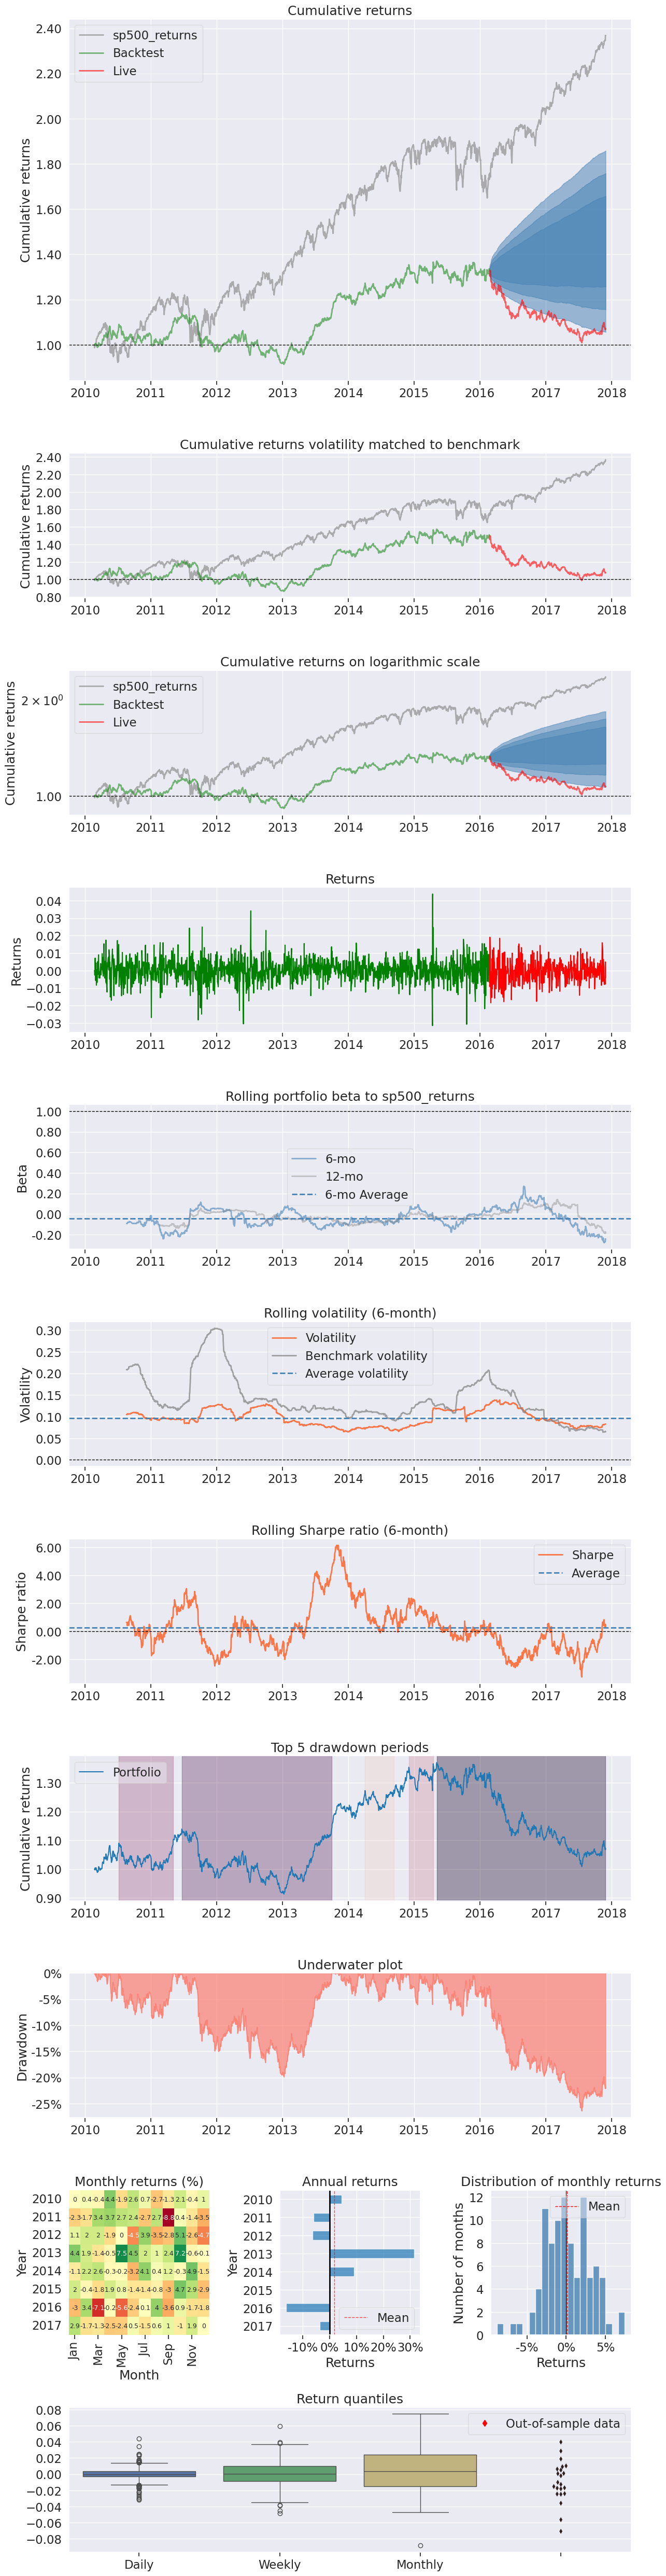

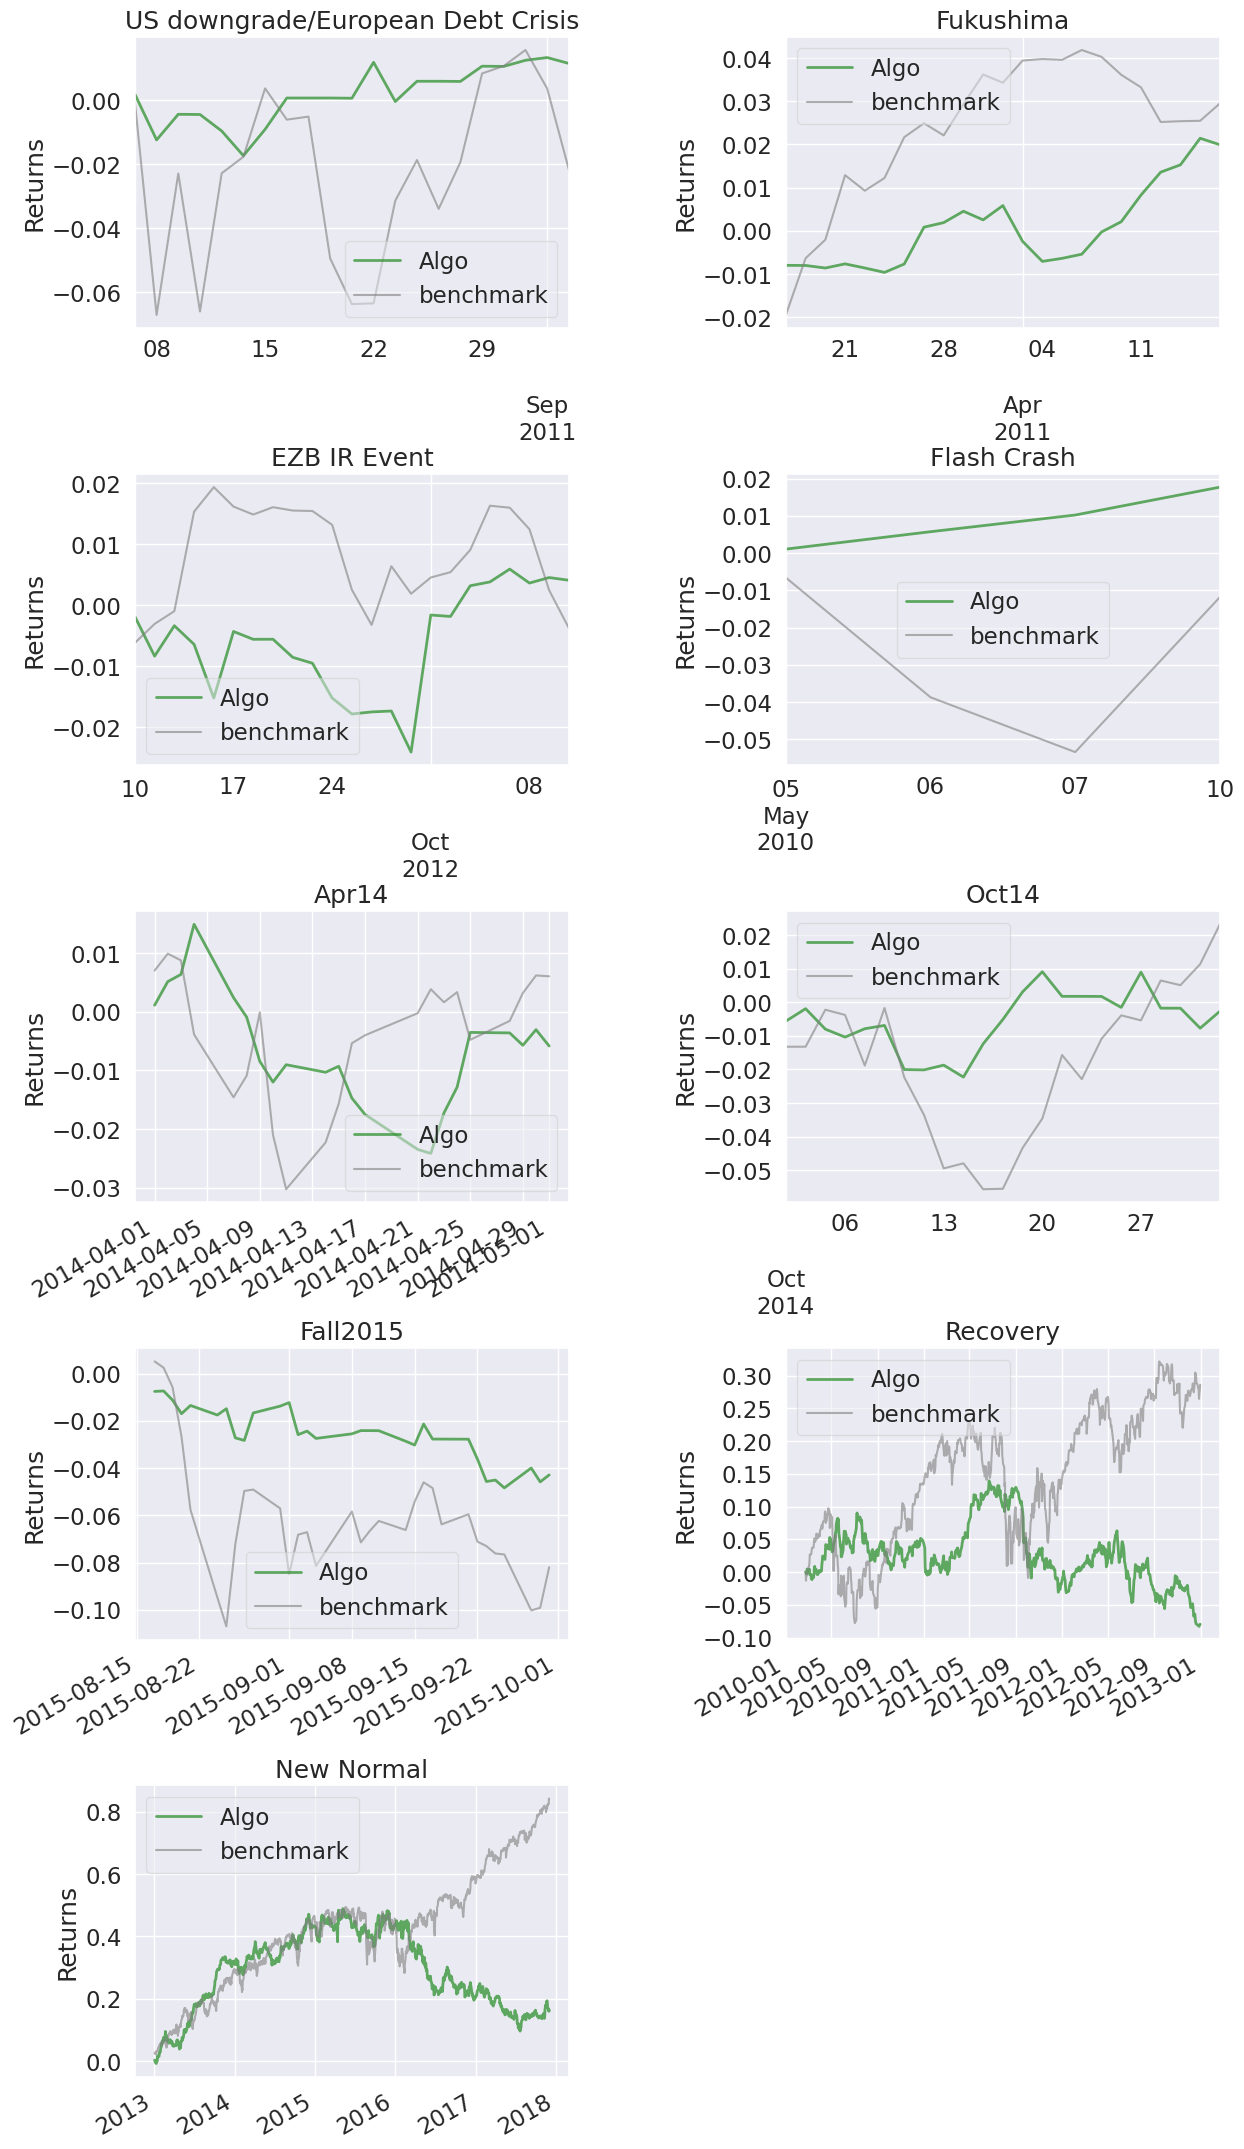

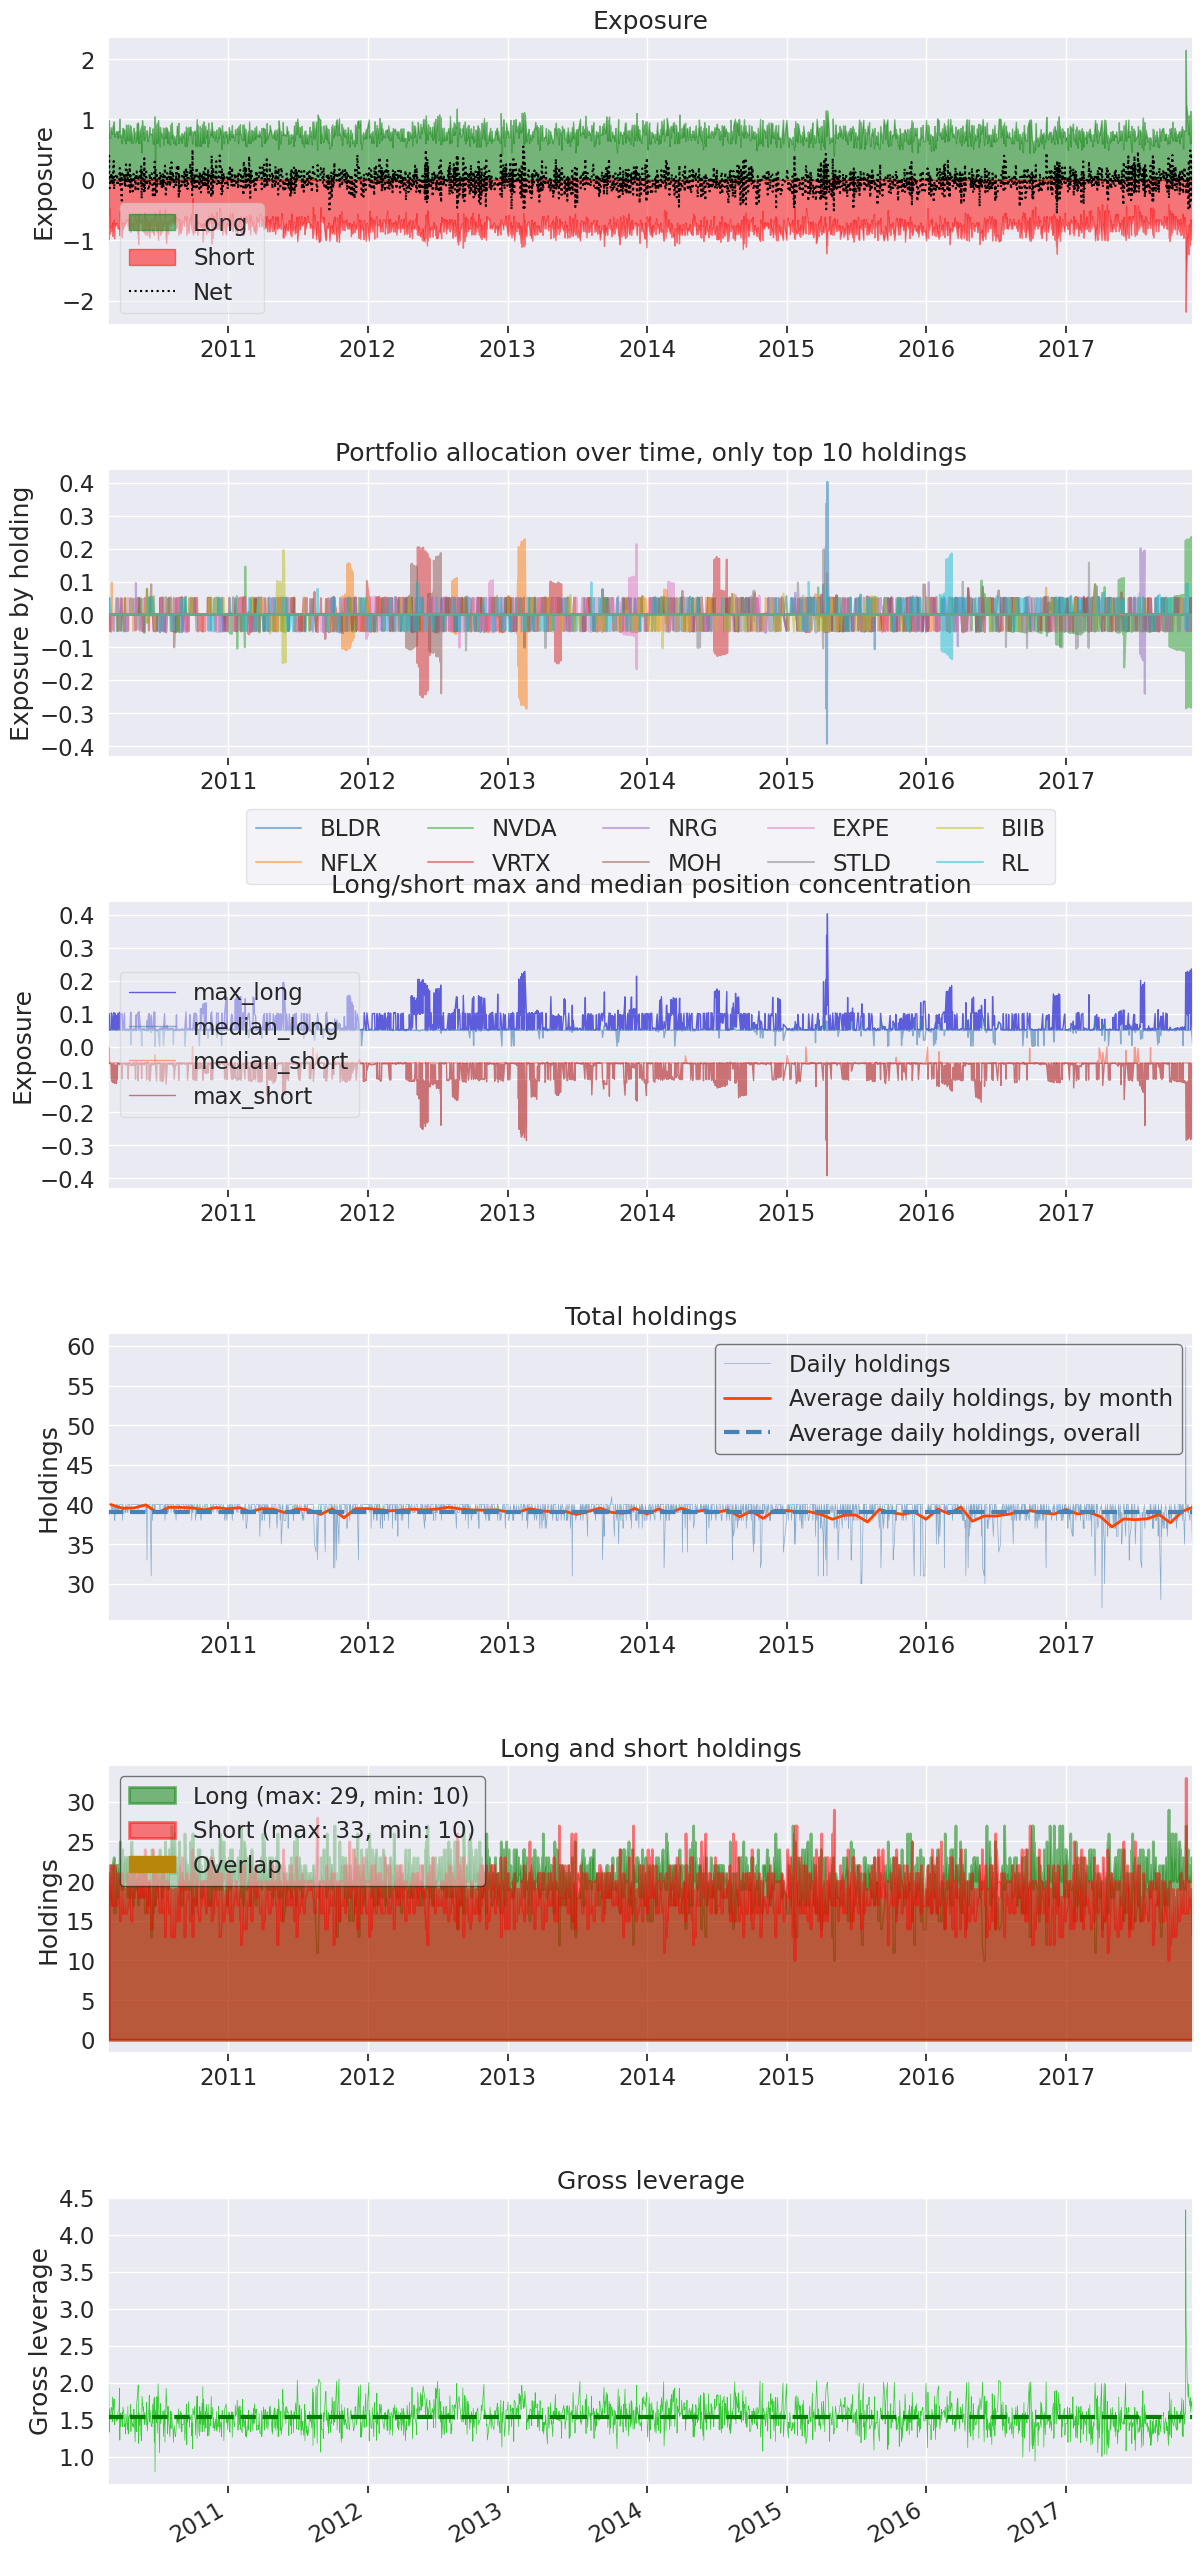

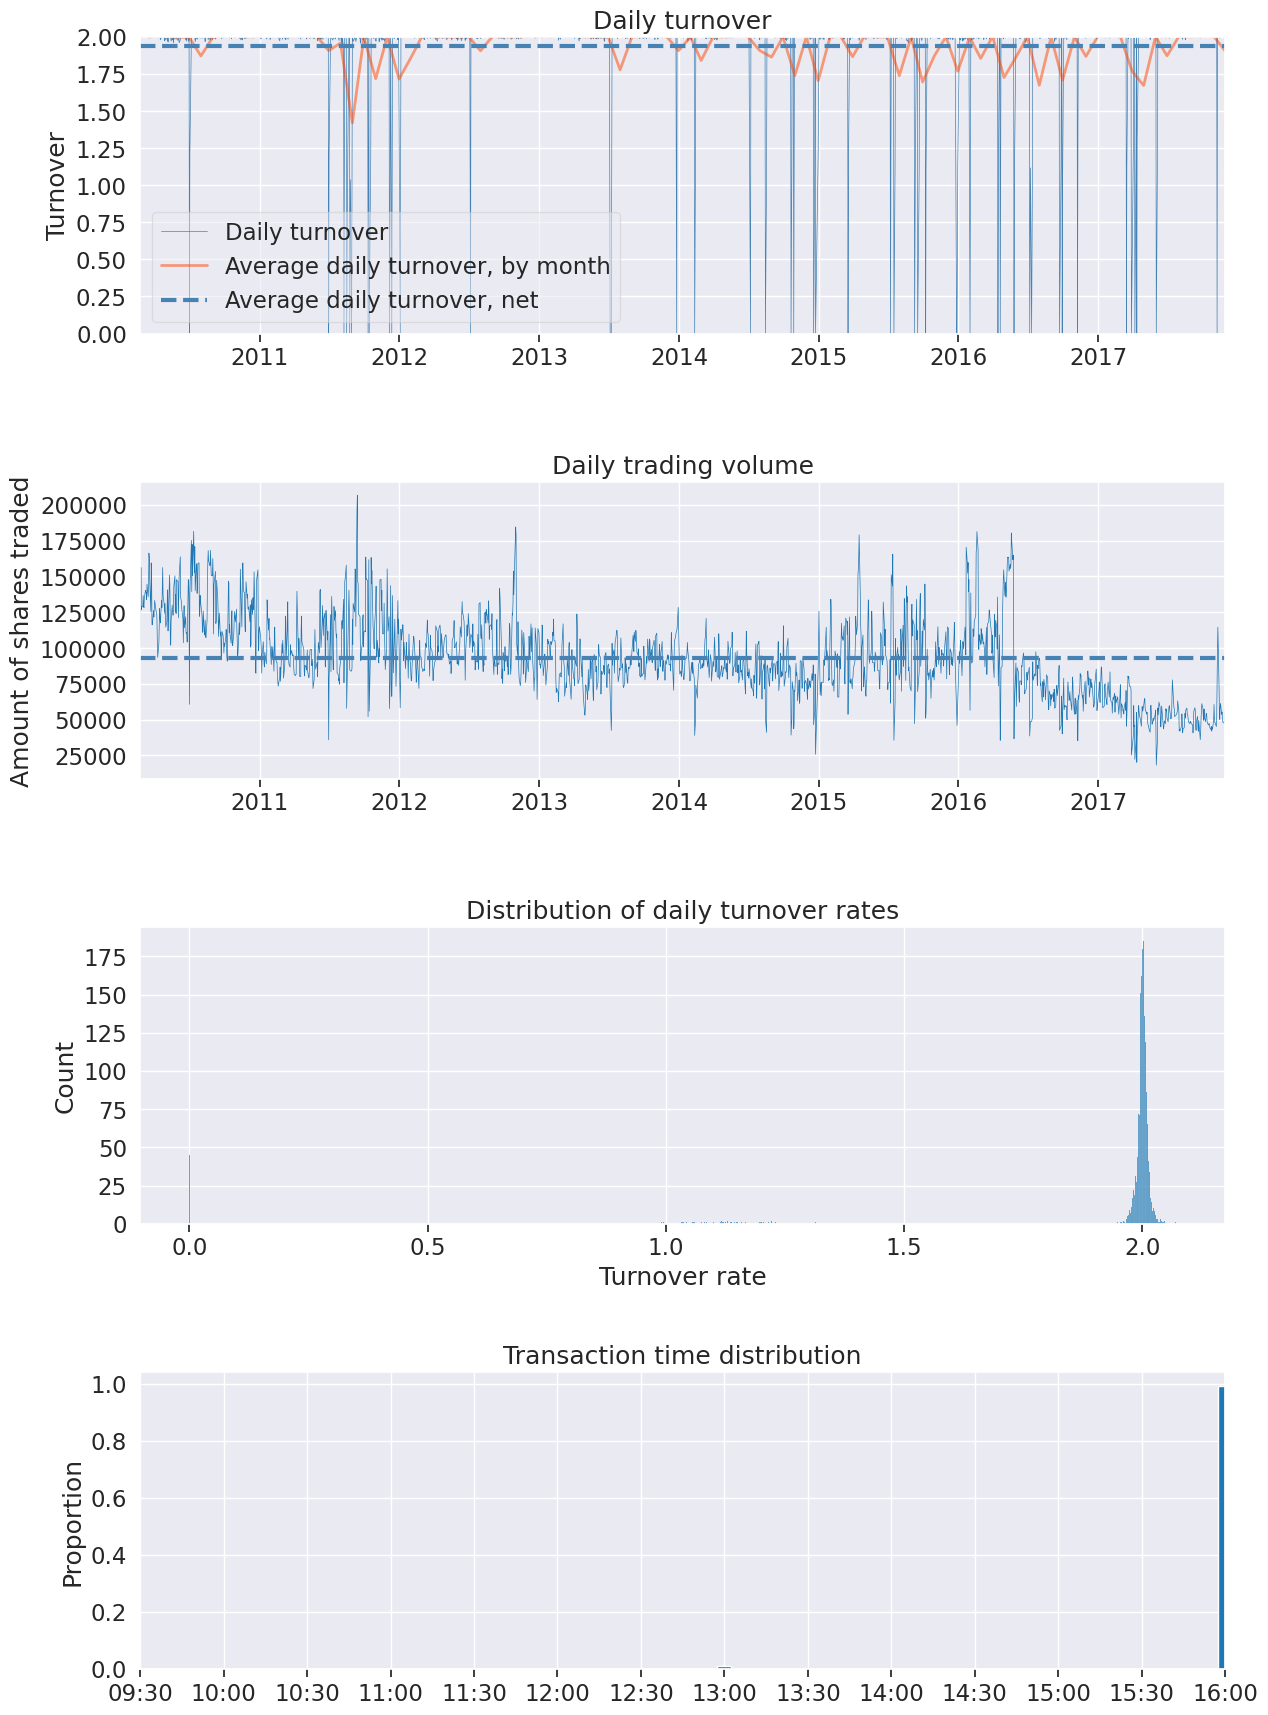

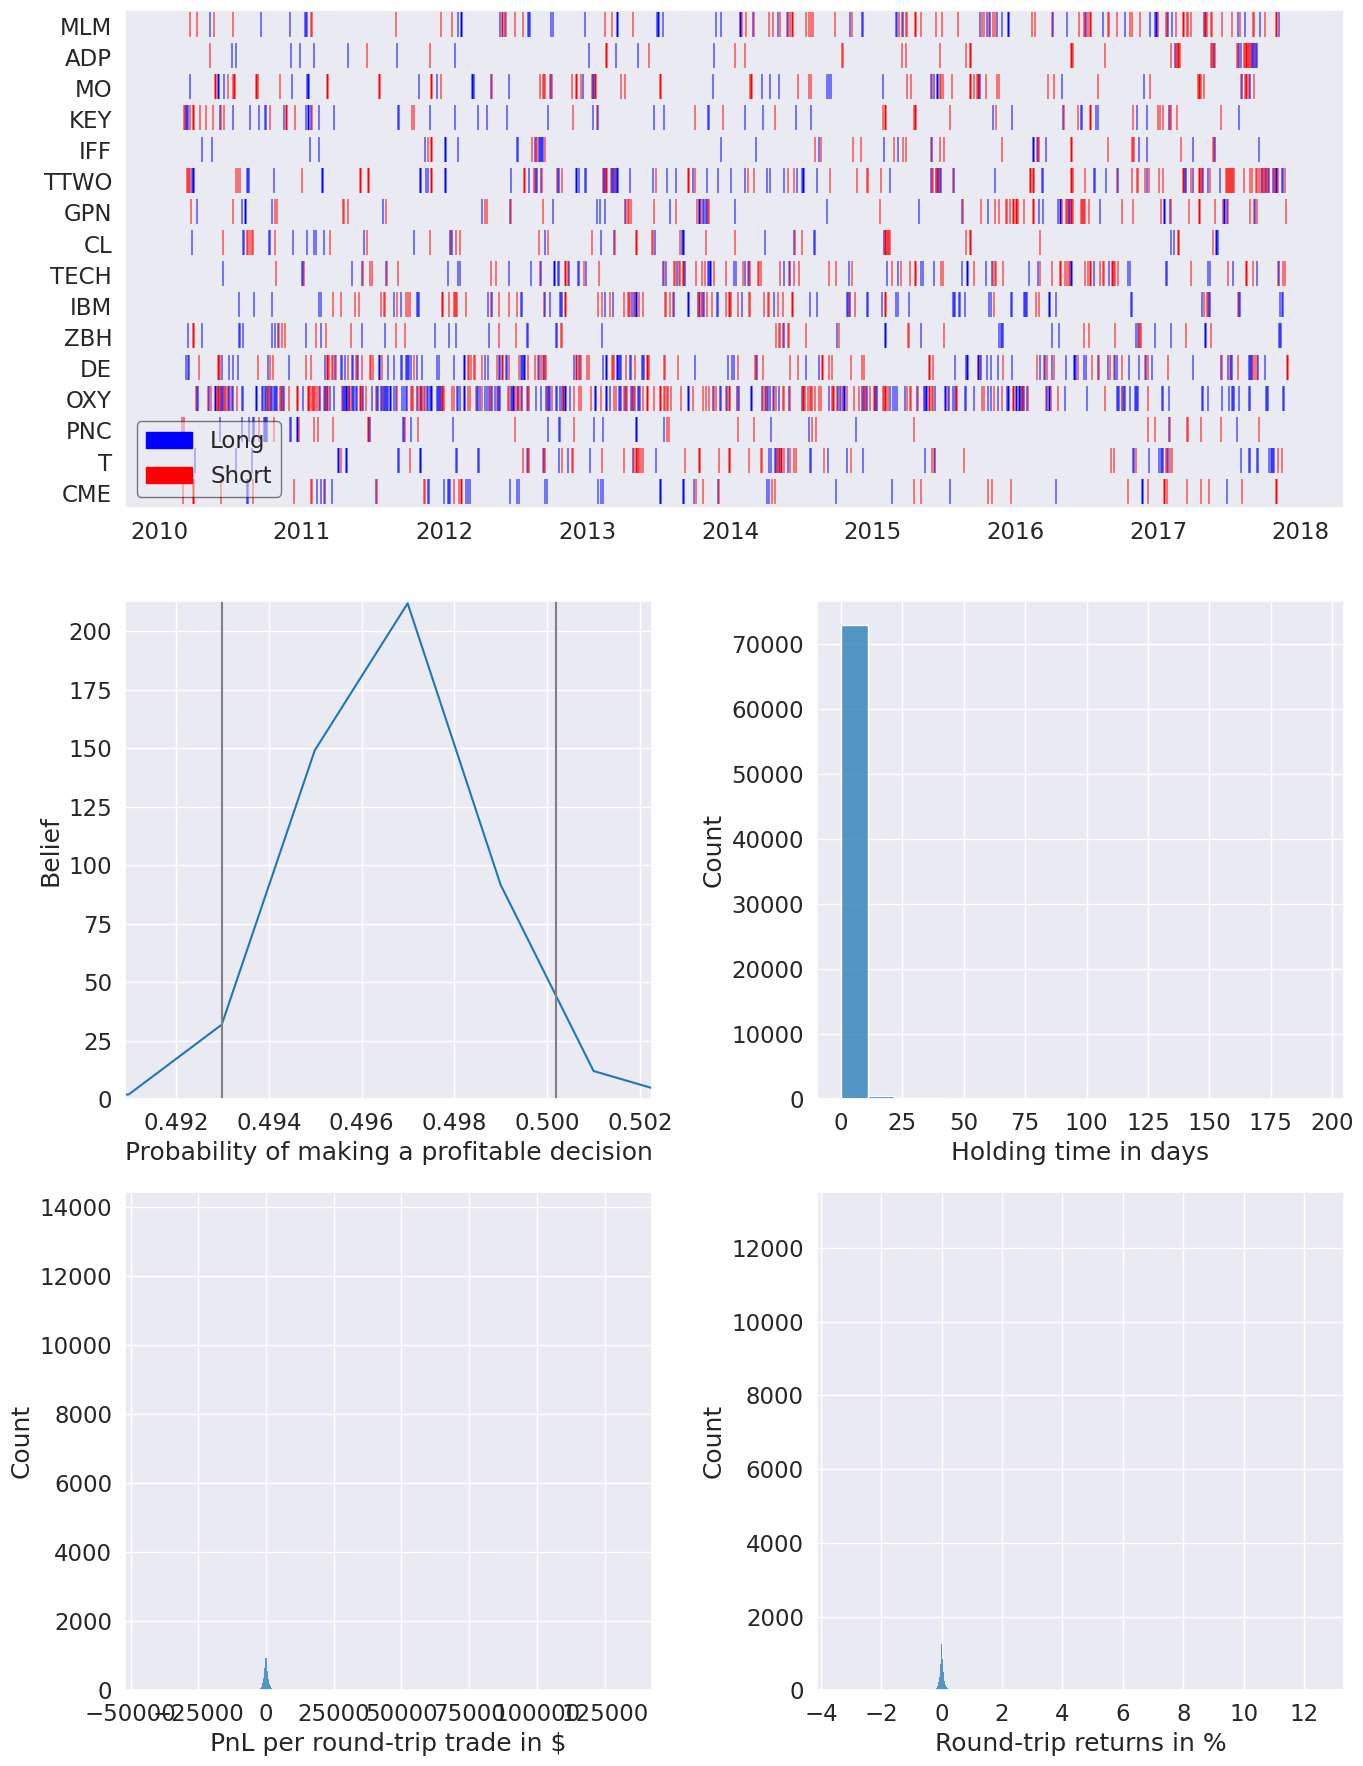

In [15]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)

## Trading Strategy-II:

### As per the Signal Evaluation of the Model-3 Factors, we will long and short predictions in quantiles 4 and 5 respectively.

In [16]:
trading_strategy={
    "strategy":"quantile_based",
    "values":{
        "quantile_long":4,
        "quantile_short":5
}

}

In [17]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model3_Factors",
    trading_strategy=trading_strategy
)

In [18]:
results=backtester.run_backtesting()

INFO: Model predictions loaded...
INFO: Missing Date Values added in Model Predictions...
INFO: Model Data Loader created...
INFO: Backtesting started for trading strategy-II...
INFO: Backtesting completed...


### Performance analysis using Pyfolio

#### Extracting information from Zipline Results

In [19]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

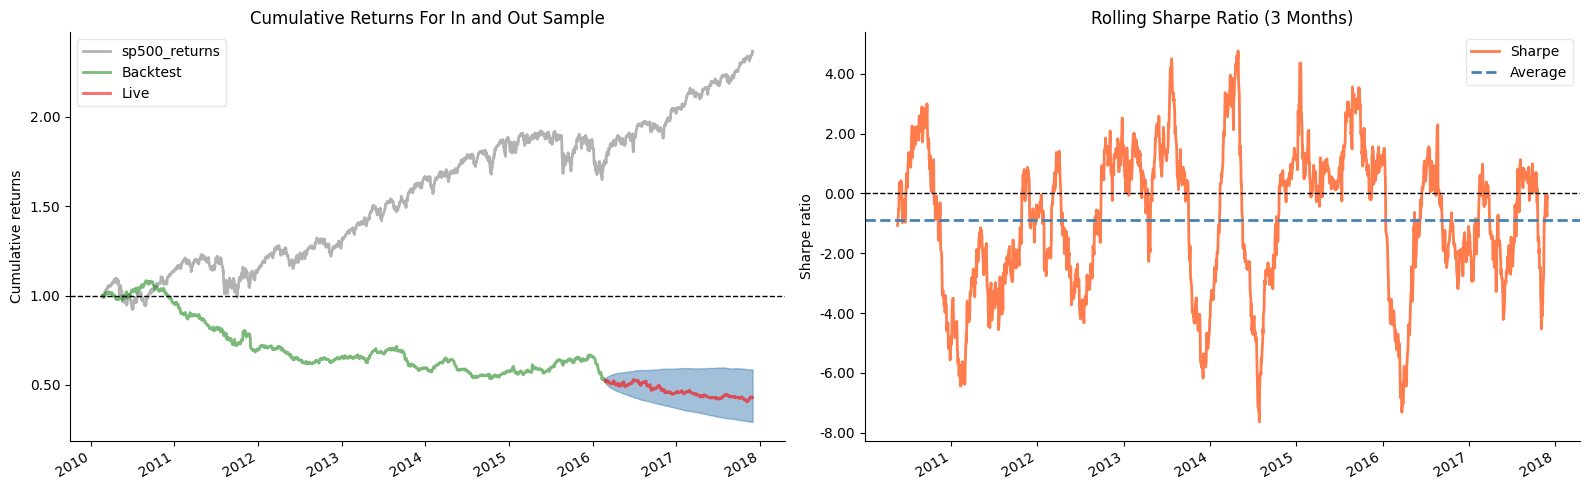

In [20]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,62.44,2010-08-31,2017-11-03,NaT,NaN
1,4.37,2010-03-23,2010-04-30,2010-06-07,55
2,3.32,2010-06-07,2010-06-10,2010-06-28,16
3,2.83,2010-07-21,2010-07-22,2010-07-30,8
4,1.34,2010-08-12,2010-08-18,2010-08-23,8


Stress Events,mean,min,max
US downgrade/European Debt Crisis,-0.13%,-3.87%,1.82%
Fukushima,-0.04%,-0.91%,0.89%
EZB IR Event,0.07%,-0.81%,1.34%
Flash Crash,0.06%,-0.74%,0.71%
Apr14,-0.07%,-1.83%,1.28%
Oct14,0.01%,-2.43%,2.91%
Fall2015,0.03%,-1.91%,2.24%
Recovery,-0.06%,-6.56%,5.51%
New Normal,-0.03%,-4.39%,7.31%


Top 10 long positions of all time,max
sid,
CNP,48.14%
AIG,45.08%
AIZ,43.97%
BLDR,43.06%
ALL,40.20%
BK,39.31%
BMY,38.34%
CDNS,37.57%
AZO,36.16%


Top 10 short positions of all time,max
sid,
CB,-55.36%
CNP,-44.27%
AIG,-41.65%
DHI,-41.10%
ALGN,-40.26%
AIZ,-40.02%
CRM,-39.97%
BG,-38.98%
BLDR,-38.52%


Top 10 positions of all time,max
sid,
CB,55.36%
CNP,48.14%
AIG,45.08%
AIZ,43.97%
BLDR,43.06%
DHI,41.10%
ALGN,40.26%
ALL,40.20%
CRM,39.97%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$-620762.00,$-1504878.13,$884116.14
Gross profit,$16856922.89,$7744866.13,$9112056.76
Gross loss,$-17477684.89,$-9249744.26,$-8227940.63
Profit factor,$0.96,$0.84,$1.11
Avg. trade net profit,$-8.15,$-41.93,$21.96
Avg. winning trade,$447.86,$461.09,$437.20
Avg. losing trade,$-461.64,$-492.77,$-431.03
Ratio Avg. Win:Avg. Loss,$0.97,$0.94,$1.01
Largest winning trade,$38845.06,$17662.40,$38845.06
Largest losing trade,$-62438.75,$-62438.75,$-33434.85


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 16:44:45.475543299,1 days 20:39:01.218618518,1 days 13:15:57.621690756
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,124 days 01:00:00,124 days 01:00:00,113 days 00:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,-0.00%,-0.01%,0.00%
Avg returns winning,0.07%,0.07%,0.07%
Avg returns losing,-0.07%,-0.07%,-0.06%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.04%,0.04%,0.04%
Median returns losing,-0.04%,-0.04%,-0.03%
Largest winning trade,6.79%,2.89%,6.79%
Largest losing trade,-9.83%,-9.83%,-4.01%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HST,HUM,ISRG
Avg returns all round_trips,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.01%,-0.00%,-0.00%,0.01%,0.01%,0.01%,0.00%,-0.02%,-0.02%,0.01%,-0.01%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.01%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,-0.00%,0.00%,-0.01%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.01%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.02%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.02%,0.00%,-0.00%,-0.01%,-0.01%,0.01%,-0.00%,0.00%,0.00%,0.01%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.01%,0.00%,0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.05%,0.01%,0.00%,-0.02%,-0.01%,0.01%,0.01%,-0.00%,-0.01%,-0.00%,0.00%,-0.01%,-0.01%,-0.01%,0.00%,-0.00%,0.01%,-0.01%,0.00%,-0.00%,-0.01%,-0.00%,-0.01%,0.01%,0.00%,0.05%,0.02%,0.03%,0.02%,0.00%,0.02%,-0.02%,0.02%,-0.01%,-0.02%,0.00%,0.02%,0.08%,0.00%,-0.07%,-0.02%,0.02%,-0.02%,0.00%,-0.02%,-0.07%,0.03%,0.05%,0.07%,0.13%,0.01%,-0.00%,-0.09%,0.05%,0.03%,-0.05%,0.13%,-0.04%,-0.02%
Avg returns winning,0.08%,0.04%,0.06%,0.08%,0.06%,0.05%,0.09%,0.05%,0.05%,0.06%,0.05%,0.07%,0.06%,0.04%,0.08%,0.11%,0.06%,0.07%,0.12%,0.09%,0.07%,0.08%,0.05%,0.04%,0.09%,0.10%,0.05%,0.05%,0.06%,0.05%,0.07%,0.10%,0.06%,0.05%,0.05%,0.06%,0.07%,0.09%,0.06%,0.08%,0.05%,0.08%,0.08%,0.08%,0.06%,0.17%,0.06%,0.06%,0.05%,0.06%,0.07%,0.06%,0.08%,0.05%,0.06%,0.07%,0.05%,0.05%,0.06%,0.08%,0.10%,0.05%,0.06%,0.06%,0.05%,0.04%,0.04%,0.07%,0.09%,0.07%,0.05%,0.09%,0.08%,0.07%,0.07%,0.07%,0.05%,0.08%,0.06%,0.06%,0.09%,0.05%,0.07%,0.07%,0.04%,0.07%,0.05%,0.06%,0.04%,0.08%,0.06%,0.09%,0.06%,0.06%,0.07%,0.05%,0.05%,0.05%,0.05%,0.06%,0.06%,0.06%,0.04%,0.10%,0.05%,0.07%,0.09%,0.07%,0.08%,0.04%,0.03%,0.04%,0.04%,0.05%,0.05%,0.04%,0.06%,0.06%,0.03%,0.07%,0.03%,0.04%,0.04%,0.05%,0.02%,0.04%,0.04%,0.05%,0.09%,0.06%,0.08%,0.12%,0.05%,0.07%,0.04%,0.06%,0.09%,0.01%,0.08%,0.05%,0.08%,0.05%,0.11%,0.05%,0.02%,0.03%,0.03%,0.03%,NaN,0.03%,0.05%,0.07%,0.13%,0.12%,0.03%,NaN,0.05%,0.03%,NaN,0.13%,NaN,NaN
Avg returns losing,-0.08%,-0.05%,-0.05%,-0.07%,-0.07%,-0.05%,-0.08%,-0.05%,-0.05%,-0.07%,-0.06%,-0.08%,-0.07%,-0.04%,-0.08%,-0.10%,-0.05%,-0.07%,-0.16%,-0.11%,-0.06%,-0.08%,-0.05%,-0.05%,-0.10%,-0.11%,-0.04%,-0.06%,-0.07%,-0.05%,-0.06%,-0.10%,-0.06%,-0.05%,-0.06%,-0.06%,-0.06%,-0.09%,-0.06%,-0.09%,-0.04%,-0.08%,-0.07%,-0.10%,-0.08%,-0.17%,-0.06%,-0.05%,-0.05%,-0.05%,-0.07%,-0.06%,-0.08%,-0.04%,-0.06%,-0.08%,-0.04%,-0.06%,-0.07%,-0.07%,-0.11%,-0.05%,-0.06%,-0.07%,-0.05%,-0.05%,-0.04%,-0.10%,-0.09%,-0.07%,-0.04%,-0.10%,-0.07%,-0.07%,-0.06%,-0.07%,-0.05%,-0.06%,-0.06%,-0.07%,-0.10%,-0.06%,-0.06%,-0.08%,-0.04%,-0.06%,-0.05%,-0.06%,-0.05%,-0.08%,-0.05%,-0.09%,-0.06%,-0.05%,-0.07%,-0.04%,-0.04%,-0.06%,-0.05%,-0.06%,-0.06%,-0.06%,-0.04%,-0.19%,-0.03%,-0.07%,-0.11%,-0.08%,-0.07%,-0.04%,-0.03%,-0.06%,-0.04%,-0.04%,-0.08%,-0.06%,-0.08%,-0.06%,-0.04%,-0.06%,-0.05%,-0.04%,-0.04%,-0.07%,-0.04%,-0.06%,-0.03%,-0.04%,-0.06%,-0.04%,-0.04%,-0.09%,-0.04%,-0.03%,-0.06%,-0.05%,-0.09%,-0.04%,-0.07%,-0.03%,NaN,-0.03%,-0.16%,-0.04%,NaN,-0.09%,-0.03%,-0.13%,-0.07%,NaN,NaN,NaN,NaN,-0.09%,-0.04%,-0.09%,NaN,NaN,-0.05%,NaN,-0.04%,-0.02%
Median returns all round_trips,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,0

Profitability (PnL / PnL total) per name,
symbol,
AME,13.25%
DUK,12.19%
AMD,10.77%
CME,9.87%
BK,8.79%
AIG,8.39%
DXCM,8.18%
AES,7.18%
BBY,6.82%


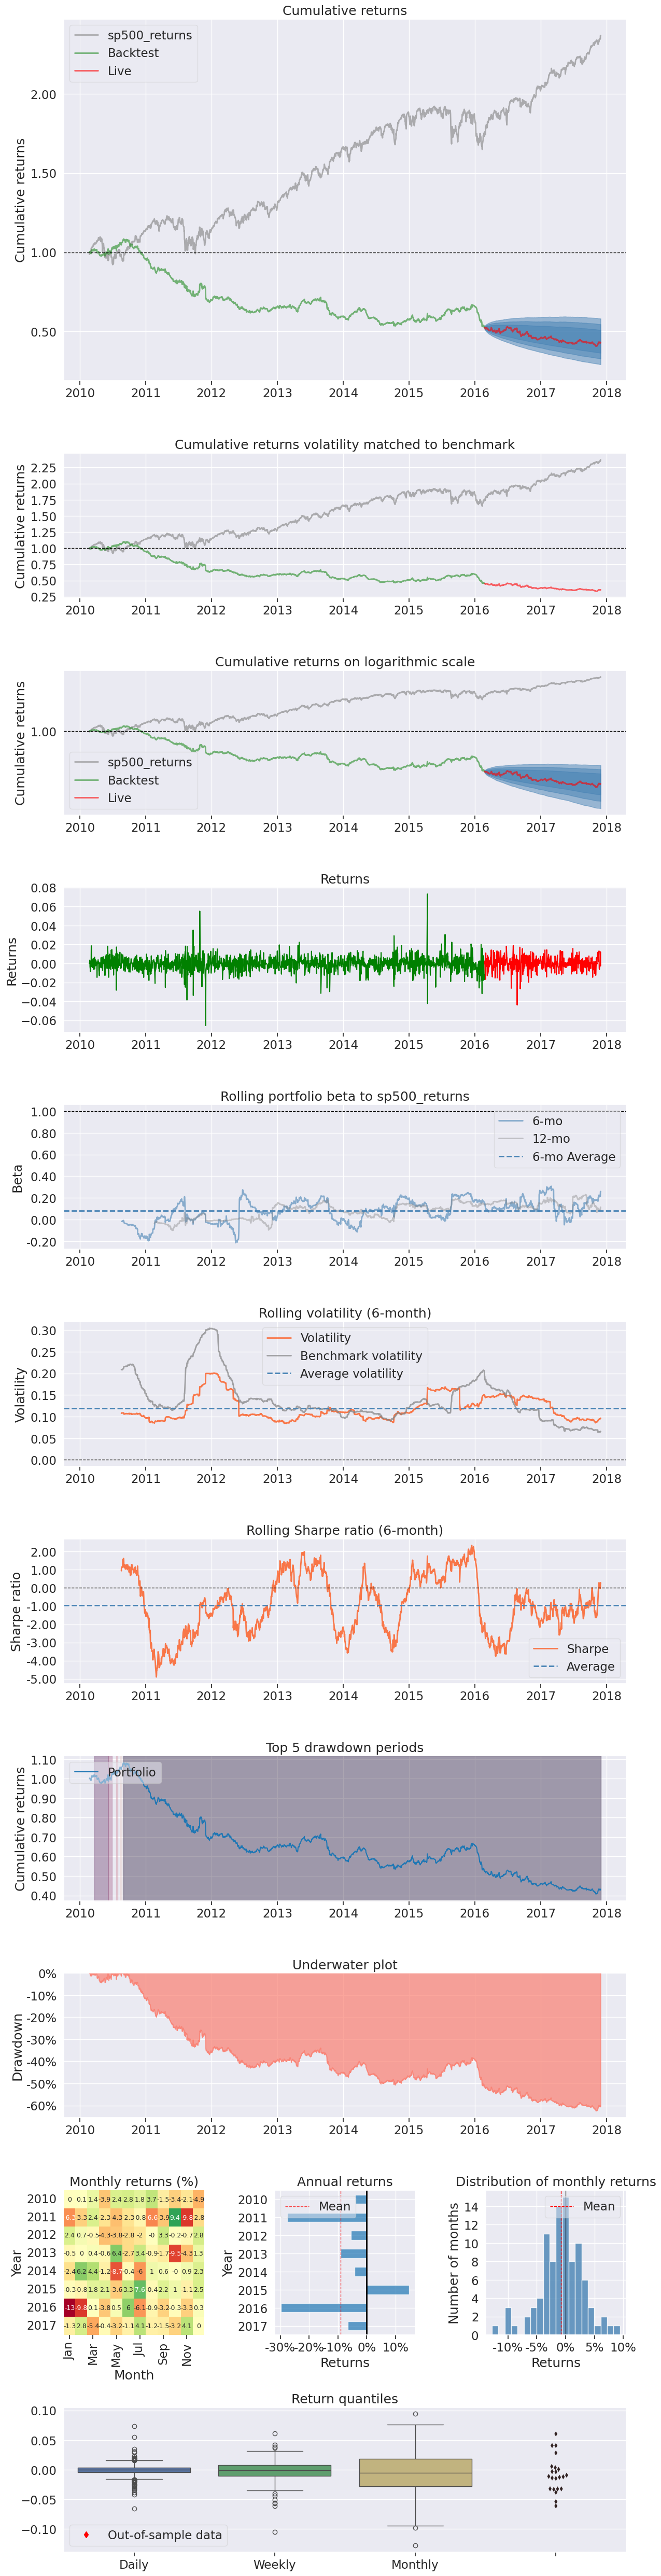

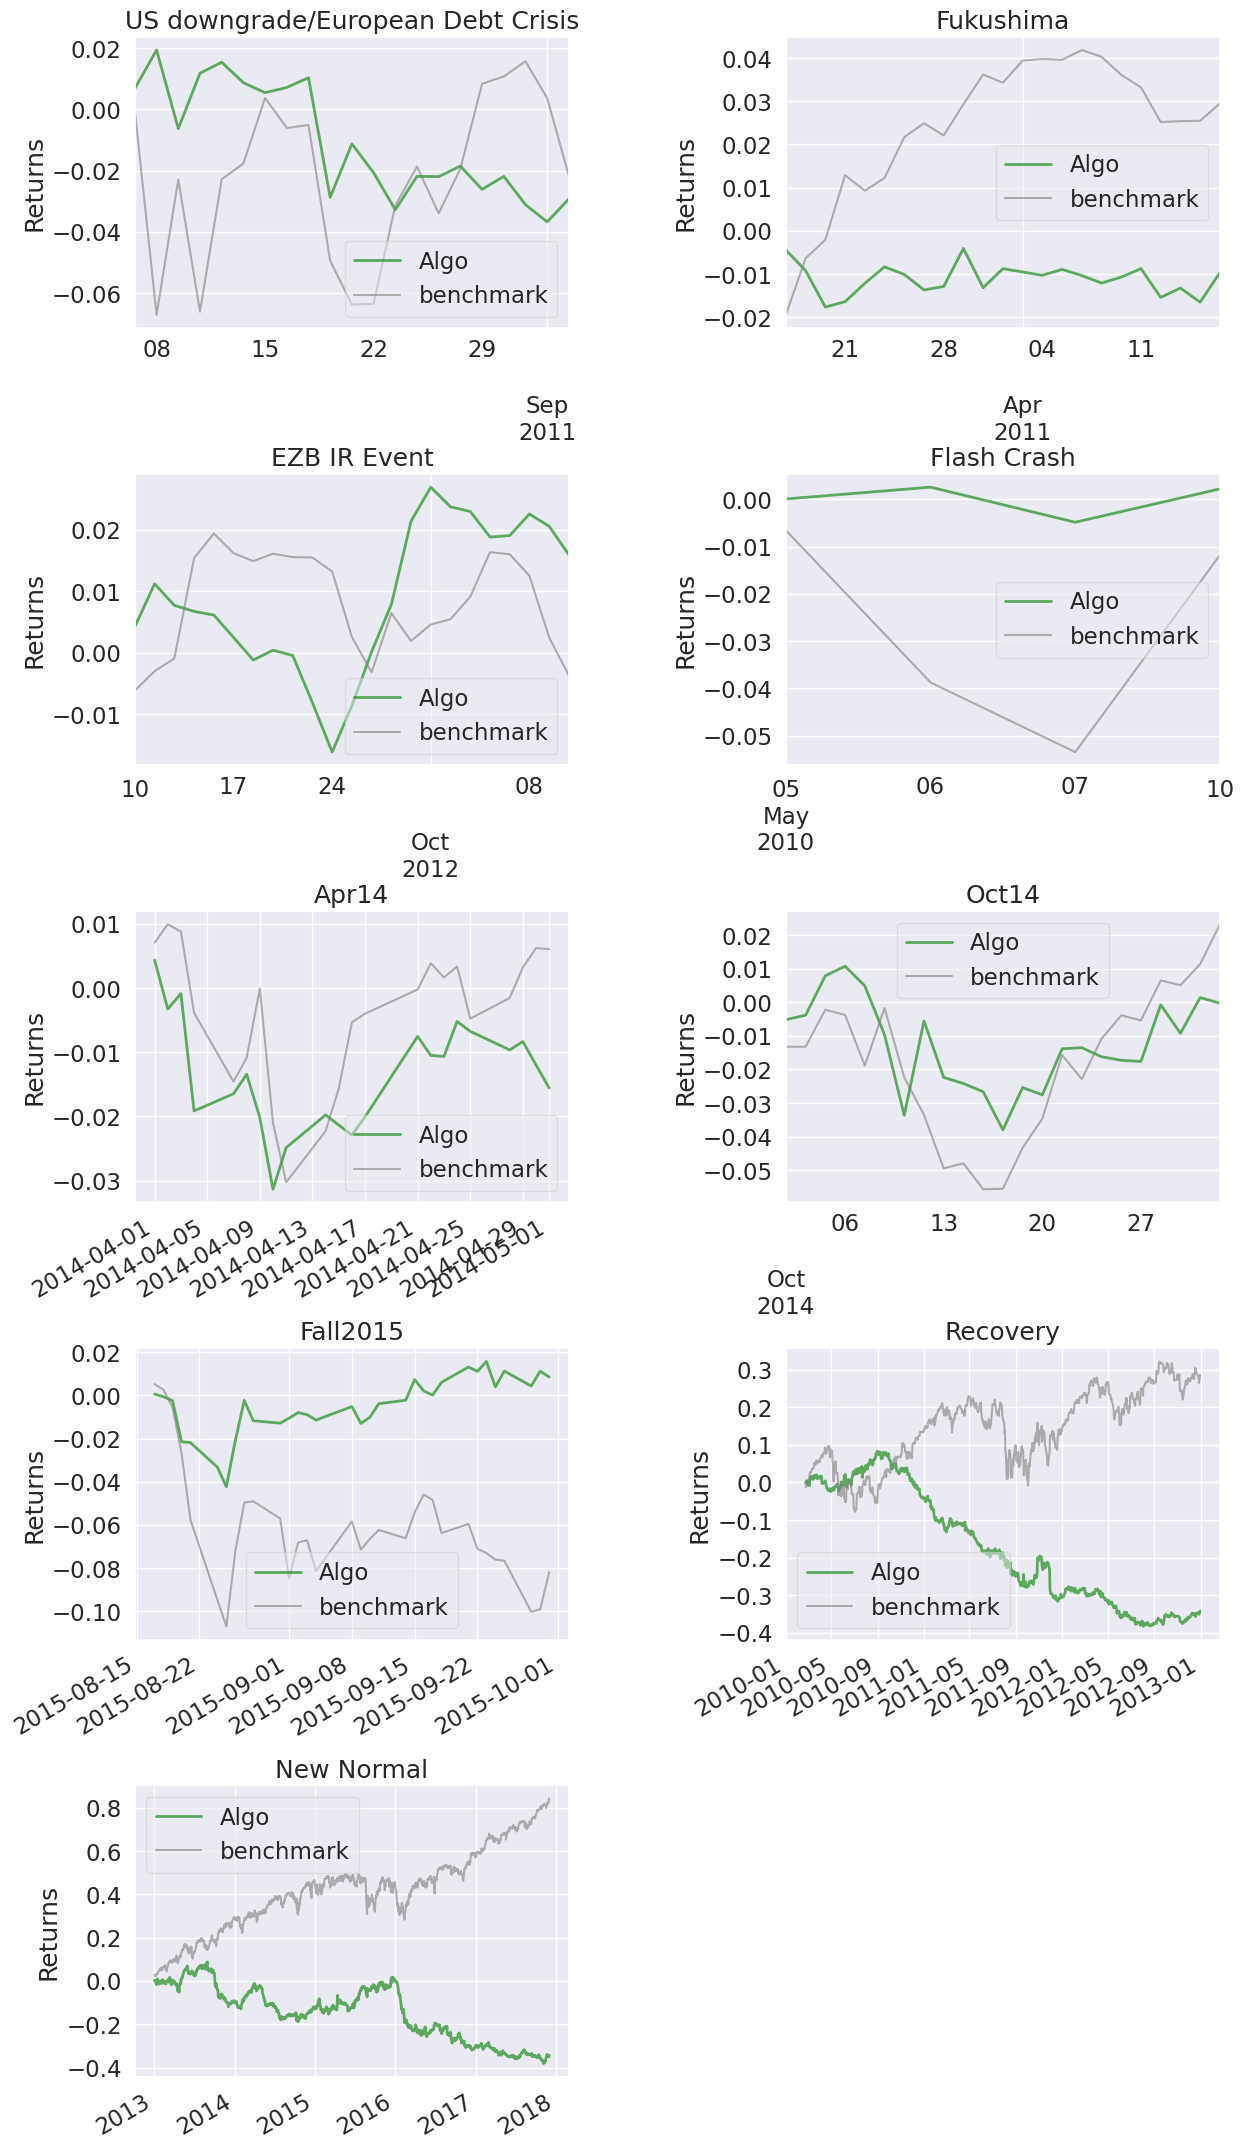

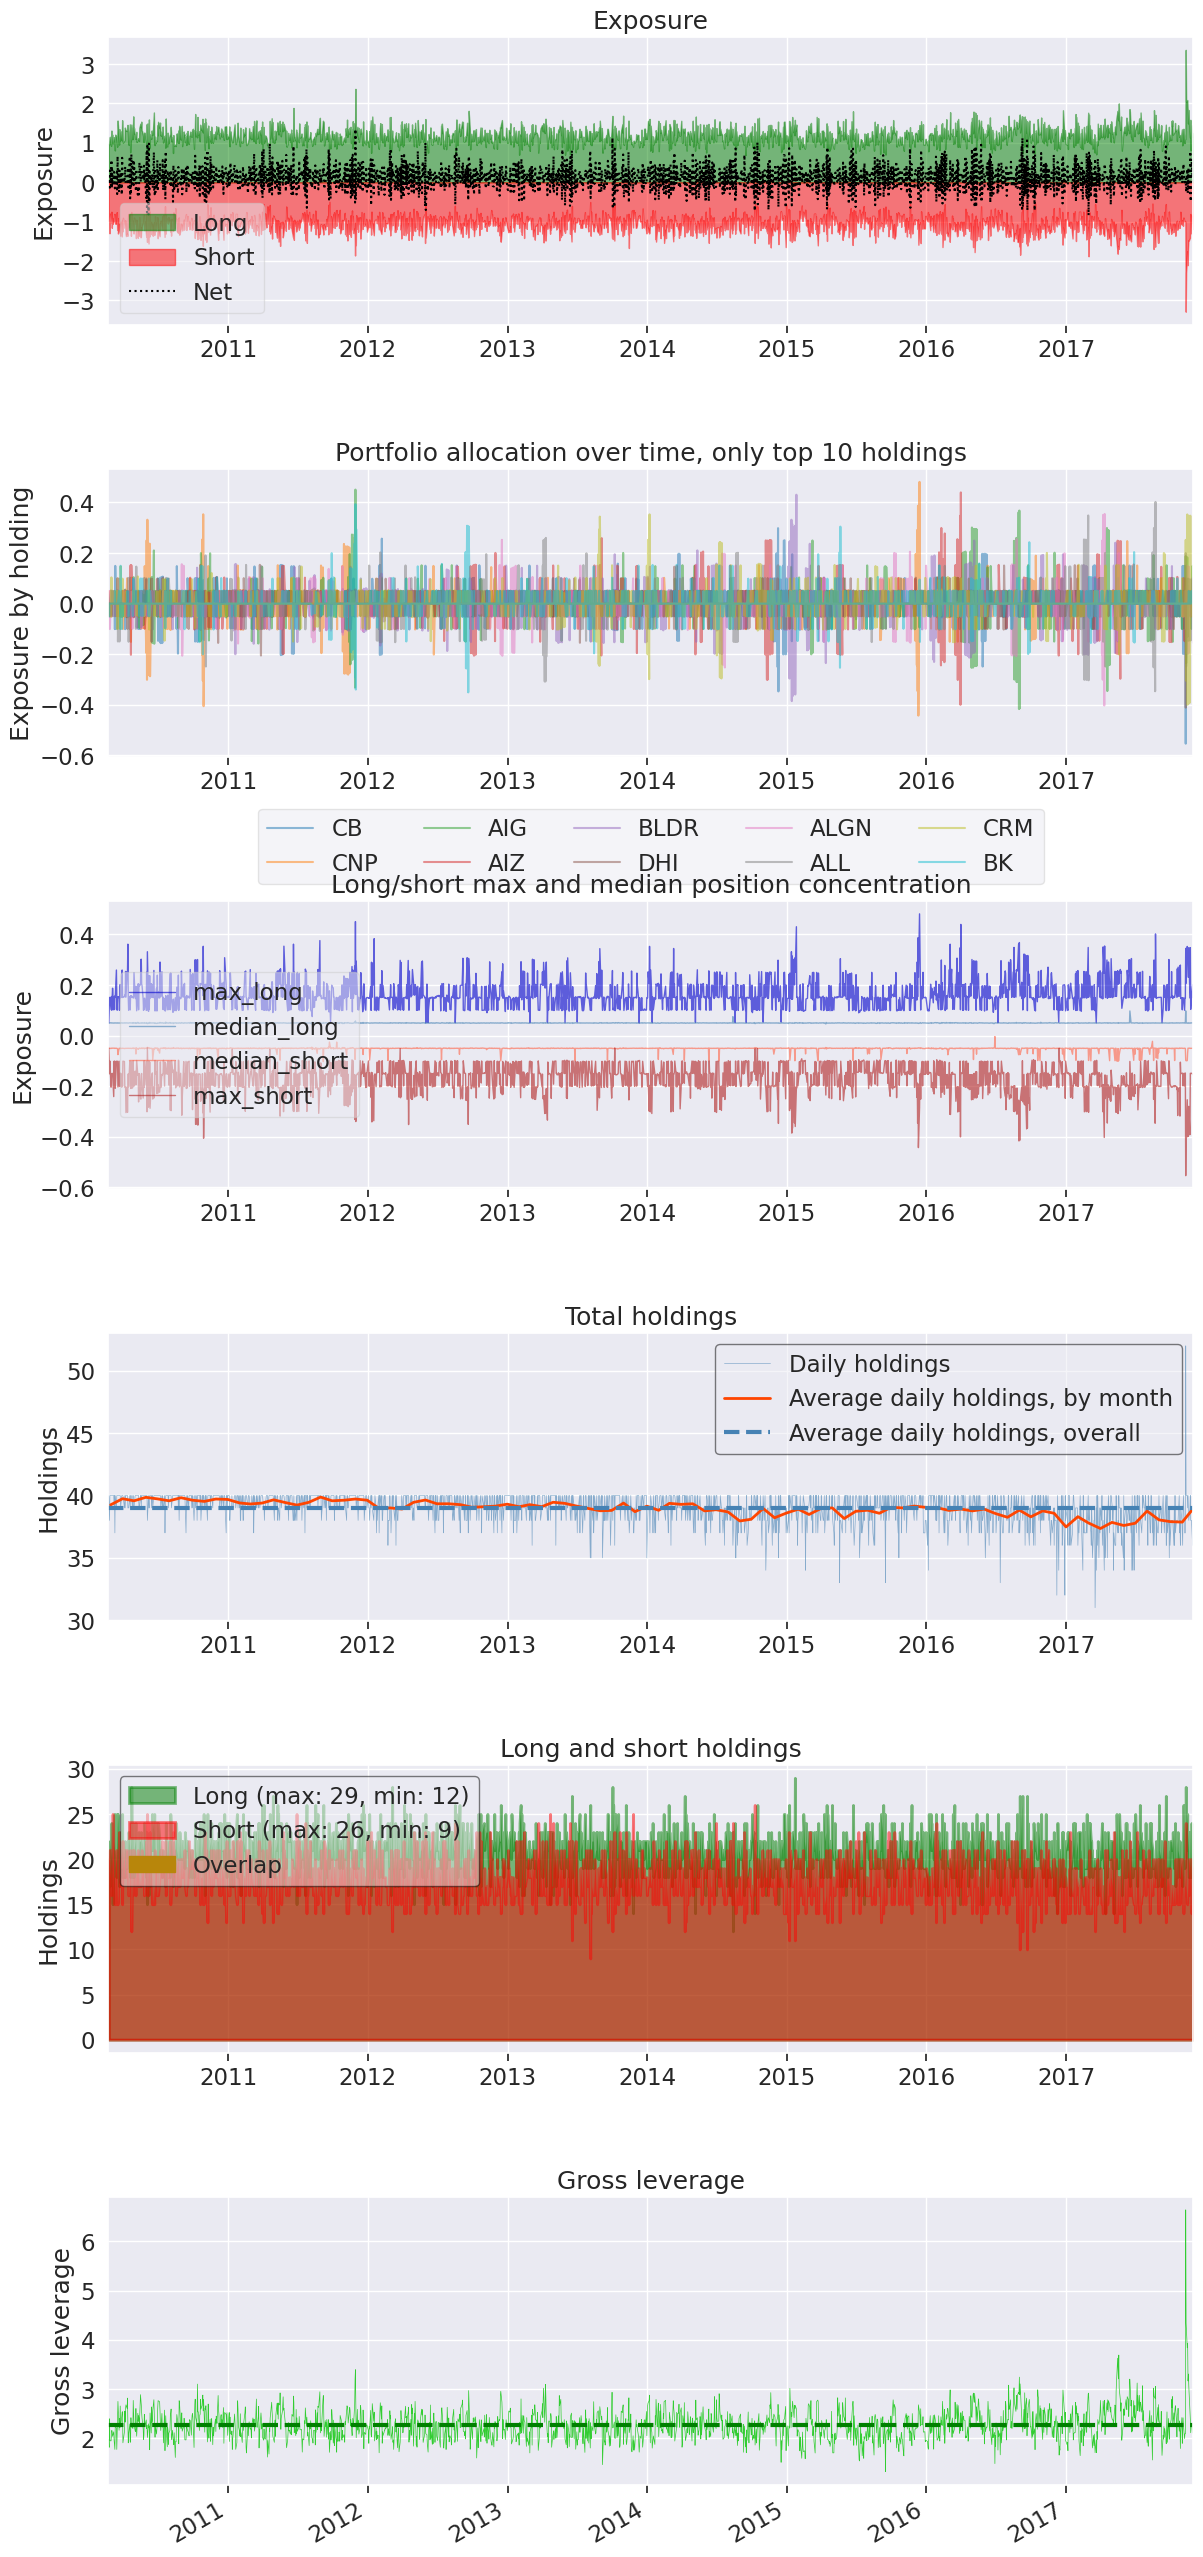

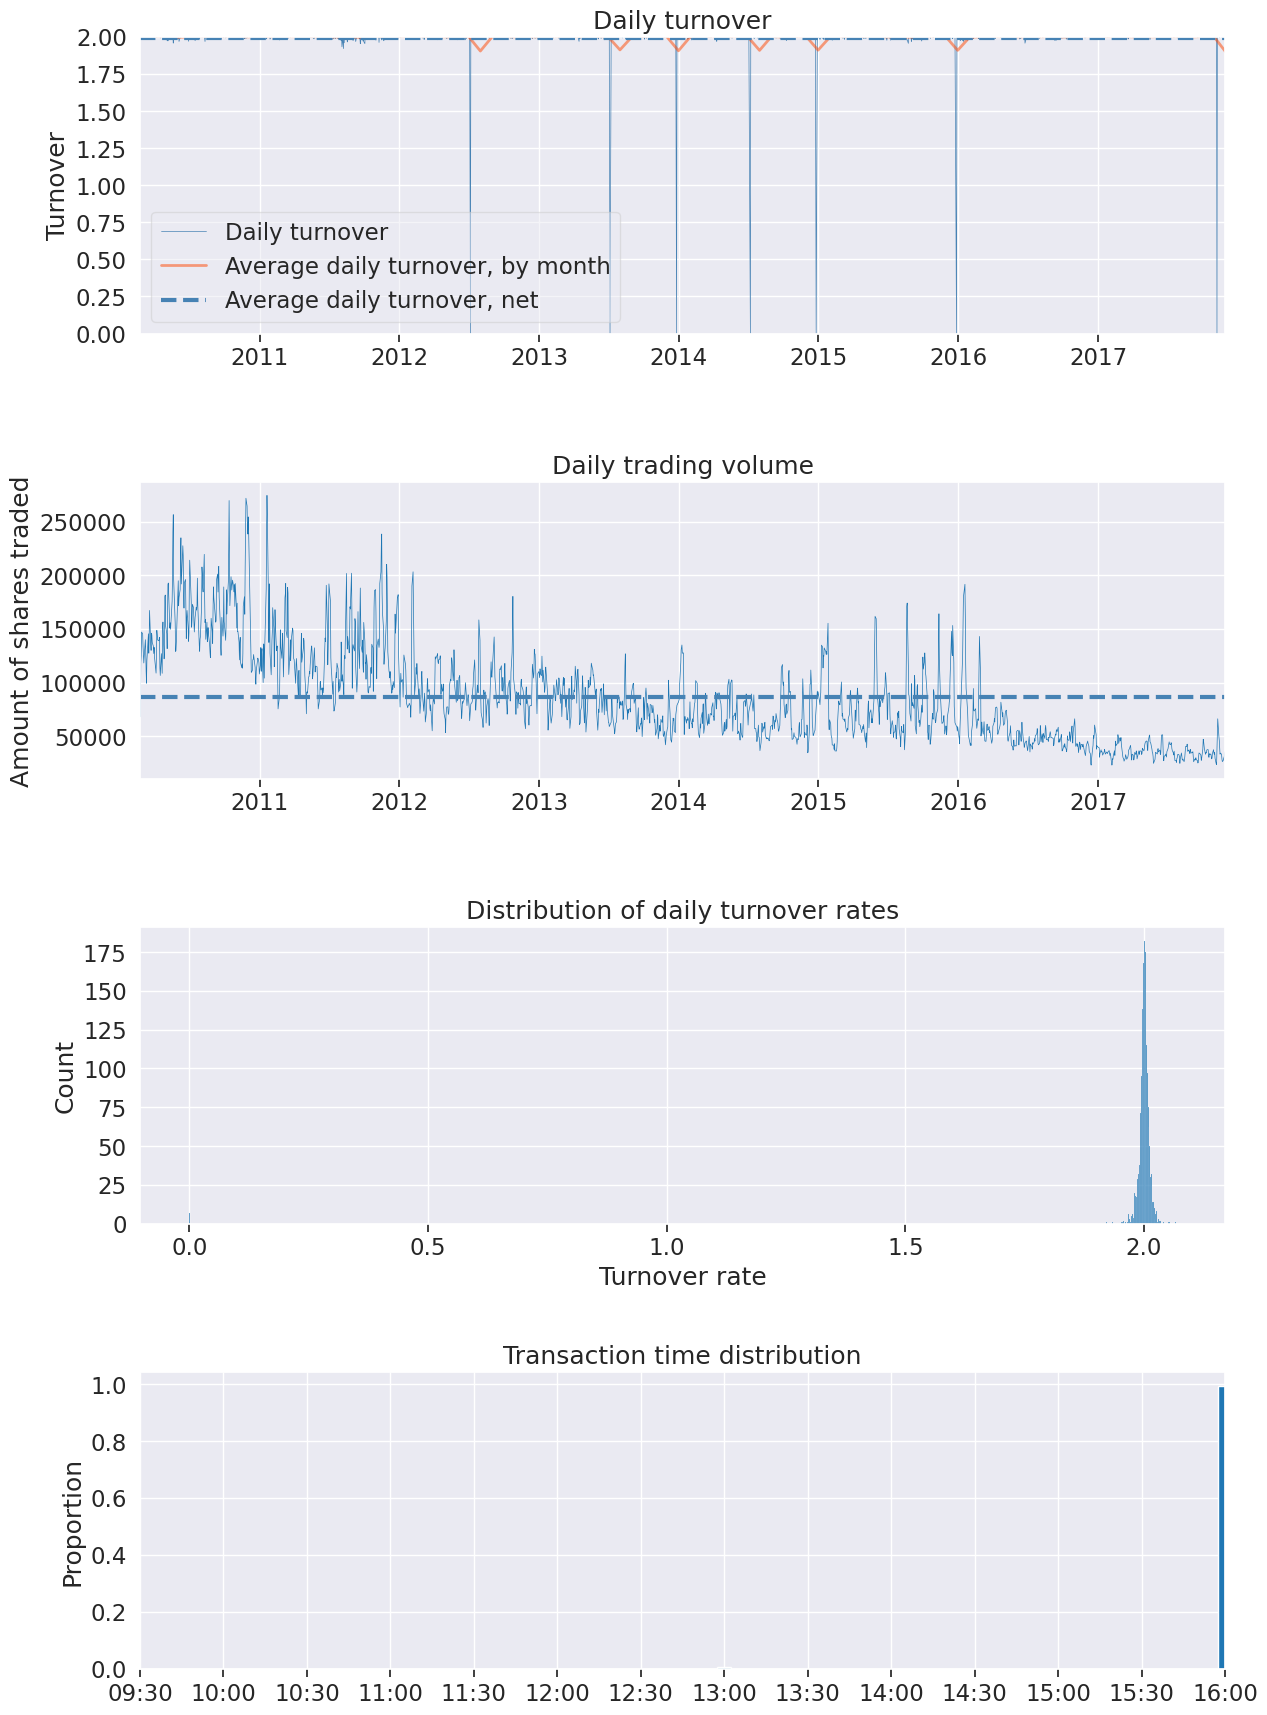

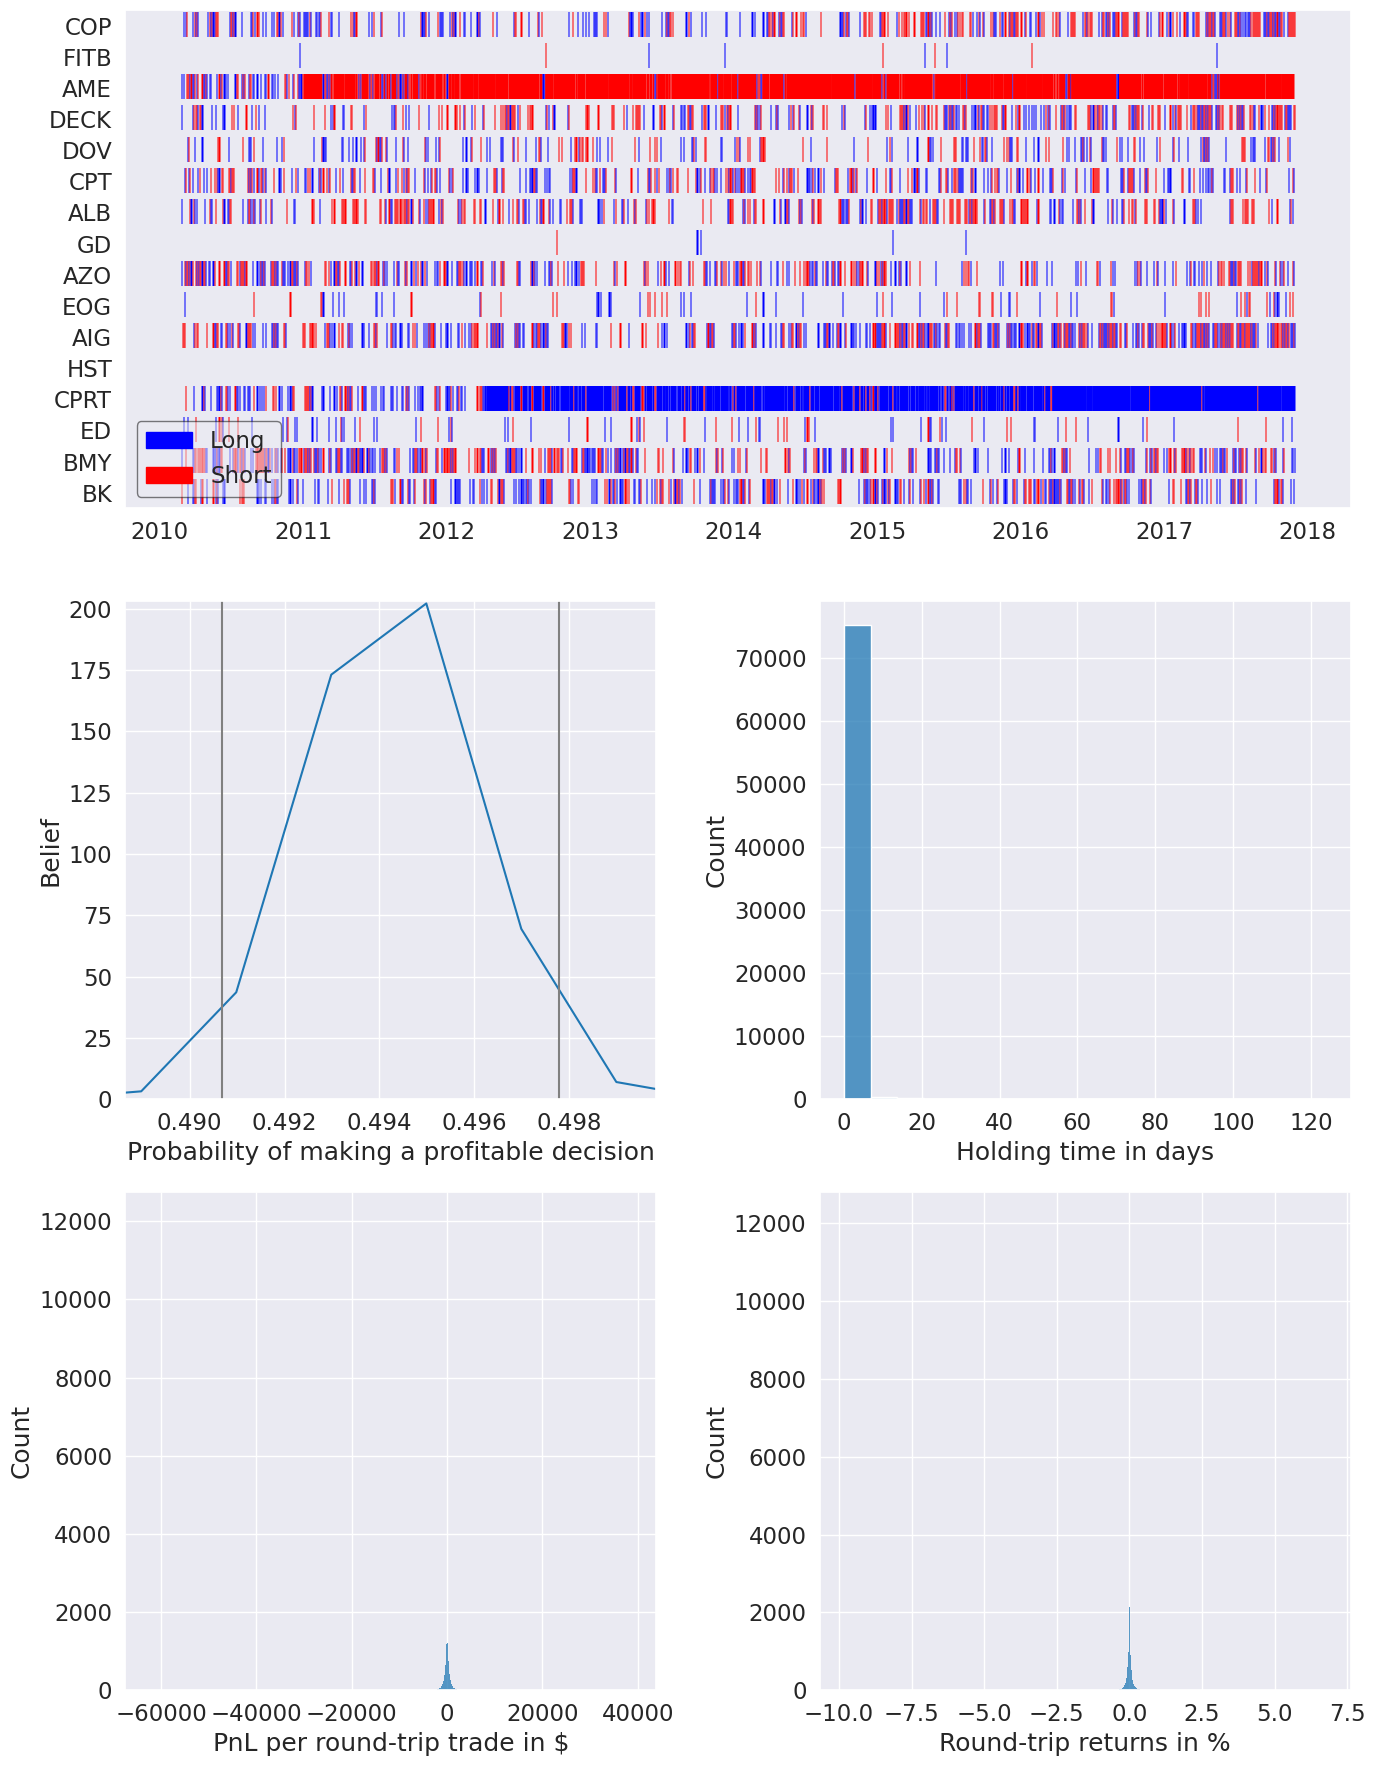

In [21]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)